<a href="https://colab.research.google.com/github/zainaBanglekar/CSL701-Roll_No_-CS03_Machine-Learning-Lab/blob/main/Experiments%20and%20Mini-Project/Practical02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Aim: To implement a Simple Linear Regression model using Python and predict MPG from Horsepower using OLS.



Objectives


*   Understand SLR

*   Load/preprocess dataset

*   Perform EDA

*   Compute OLS coefficients

*   Evaluate with SSE, MSE, R²

*   Visualize regression and residual plots











Software Requirements


*   Python 3.x

*   Jupyter/Colab/VS Code

*  Libraries: pandas, numpy, matplotlib, seaborn





Theory


Linear regression models the relationship between a target continuous variable Y and an input feature vector X using a linear equation:


yˆ=w0+w1x1


In matrix form, including the bias/intercept term X0=1:


yˆ=Xw


To find the optimal weight vector wˆ, the Ordinary Least Squares (OLS) method minimizes the Sum of Squared Errors (SSE) between actual target values y and predicted values yˆ:


SSE=i=1Nyi-yˆi2=y-XwTy-Xw


Solving for w analytically yields the normal equation:


wˆ=XTX-1XTy


Note: The inverse XTX-1 exists only if the matrix XTX is non-singular (i.e., its determinant is non-zero).


    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2 

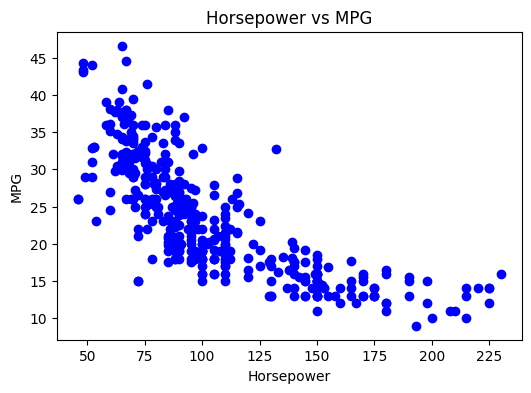

Correlation: -0.7784267838977756
Intercept: 39.9358610211705
Slope: -0.15784473335365387
SSE: 9385.915871932419
MSE: 23.943662938603108
R²: 0.6059482578894348


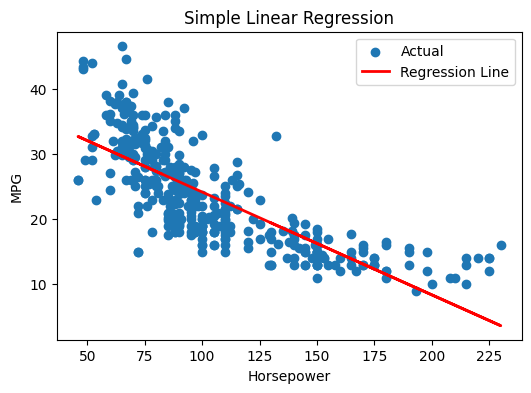

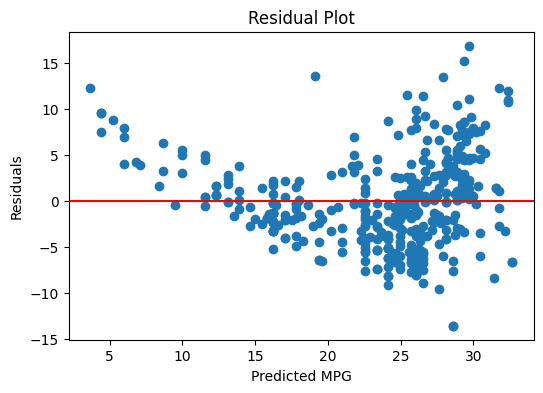


Interpretation:
Correlation = -0.778
R² = 0.606
Negative correlation indicates that as horsepower increases, MPG decreases.
Higher R² indicates better model fit.


In [2]:
# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load Dataset
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(url)

# Step 3: Inspect Dataset
print(df.head())
print(df.info())

# Step 4: Clean Data
df = df[['horsepower', 'mpg']]
df = df.dropna()

# Step 5: Select Variables
X = df['horsepower'].values
y = df['mpg'].values

# Step 6: Scatter Plot
plt.figure(figsize=(6,4))
plt.scatter(X, y, color='blue')
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Horsepower vs MPG")
plt.show()

# Step 7: Add Bias Term
X_bias = np.c_[np.ones(len(X)), X]

# Step 8: Correlation
corr = np.corrcoef(X, y)[0,1]
print("Correlation:", corr)

# Step 9: OLS Weights
weights = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ y
print("Intercept:", weights[0])
print("Slope:", weights[1])

# Step 10: Predictions
y_pred = X_bias @ weights

# Step 11: Residuals
residuals = y - y_pred

# Step 12: Evaluation Metrics
SSE = np.sum(residuals**2)
MSE = np.mean(residuals**2)
R2 = 1 - SSE/np.sum((y - np.mean(y))**2)

print("SSE:", SSE)
print("MSE:", MSE)
print("R²:", R2)

# Step 13A: Regression Line
plt.figure(figsize=(6,4))
plt.scatter(X, y, label='Actual')
plt.plot(X, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

# Step 13B: Residual Plot
plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# Step 14: Interpretation
print("\nInterpretation:")
print(f"Correlation = {corr:.3f}")
print(f"R² = {R2:.3f}")
print("Negative correlation indicates that as horsepower increases, MPG decreases.")
print("Higher R² indicates better model fit.")

Conclusion


The experiment successfully implemented Simple Linear Regression using OLS. Horsepower showed a negative relationship with MPG, and evaluation metrics demonstrated reasonable predictive performance.
